In [96]:
#Quinlin Neuhaus MATH 5001, 2/1/26, HW1

In [97]:
import numpy as np
#from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation

In [98]:
# This shuffles the order of the data so that it's randomized
def shuffle(X,Y):
    index = np.arange(X.shape[0])
    np.random.shuffle(index)
    return X[index,:], Y[index]

# Sigmoid
def a(z):
    return 1 / (1. + np.exp(-z))

# Cross entropy loss function
def loss(theta,X,y):
    y_pred = a(X.dot(theta))
    return (-y*np.log(y_pred)-(1-y)*np.log(1-y_pred)).sum()

# Gradient, scaled by 1/n, regularization removed
def grad(theta, X, y, n):
    y_pred = a(X.dot(theta))
    return (1.0/n) * np.sum((y_pred-y)*X.T,axis=1)

In [99]:
# Generate the data, from two Gaussian distributions with different labels

n1 = 500
n2 = 500
n = n1+n2

X0 =([[1],[5]]) * np.random.normal(size=(2,n1)) + ([[7],[0]]) #second class input
Y0 = np.zeros(X0.shape[1]) #second class output

X1 =([[1],[2]]) * np.random.normal(size=(2,n2)) + ([[3],[4]]) #first class input
Y1 = np.ones(X1.shape[1]) #first class output

X = np.hstack((X0,X1))
X = np.vstack((X,np.ones(n))) # Add dimension to the input data with a 1, this is the bias
X = X.T # Represents inputs as n rows of 3 columns (x,y,1)

# Rescale data so that the mean is zero and variance is 1
mu, sig = np.mean(X,axis=0),np.std(X,axis=0)
X[:,0] = (X[:,0]-mu[0])/sig[0]
X[:,1] = (X[:,1]-mu[1])/sig[1]

Y = np.hstack((Y0,Y1))
X,Y = shuffle(X,Y)
print(X.shape,Y.shape)

(1000, 3) (1000,)


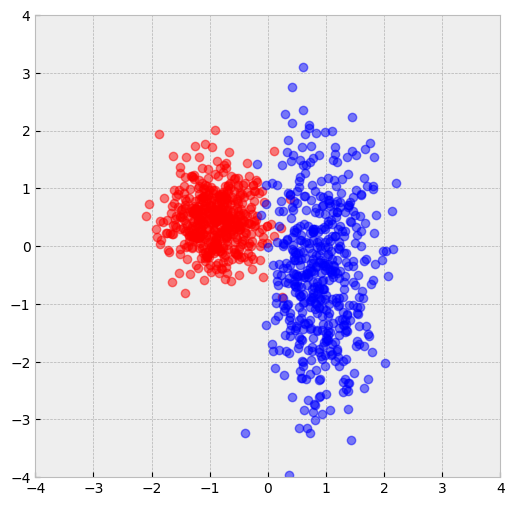

In [100]:
#Quick plot of data to ensure everything looks right 
plt.figure(figsize=(6,6))
plt.style.use('bmh')
c,d = -4,4


plt.plot(X[Y==1,0],X[Y==1,1],'o', alpha=.5, color="red")
plt.plot(X[Y==0,0],X[Y==0,1],'o', alpha=.5, color="blue")
plt.xlim(c,d)
plt.ylim(c,d)
plt.show()

575.8486070382748
80.15225282988837


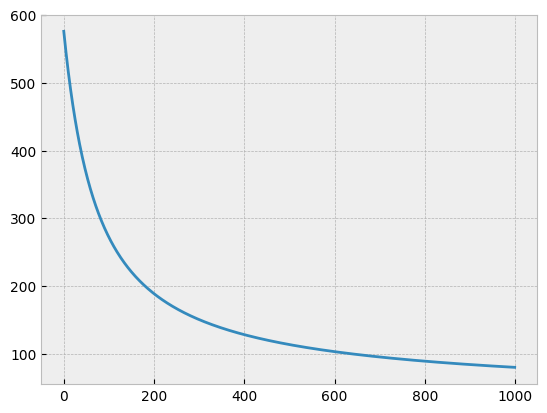

In [101]:
#Gradient descent portion
init = [0,1,0] #intial guess is flat line, allows us to visualize changing line
theta = init


lr = .05 #tried a few different one rates, .05 balanced convergence and accuracy
losslist = [] #values for loss plot
weights = [] #values for animation
print(loss(theta, X, Y)) #initial loss
for i in range(1000): #1000 is used for the animation frames, I originally used 100,000, but it quickly converges to ~50
    losslist.append(loss(theta, X, Y))
    weights.append(theta)
    gradient = grad(theta, X, Y, n) #compute gradient
    theta = theta - lr*gradient #update weights
    

y_pred = a(X.dot(theta))
print(loss(theta, X, Y)) #final loss
plt.plot(range(1000),losslist) #plot shows exponentially diminshing loss


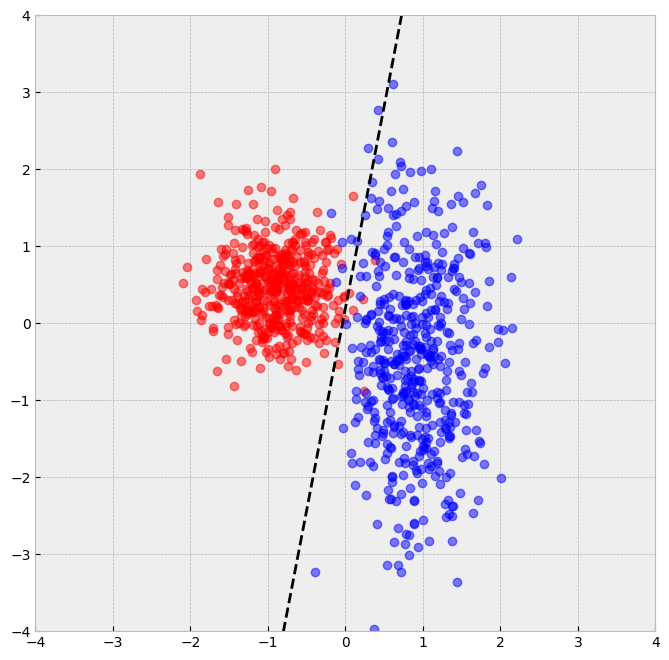

In [102]:
#Plot final decision boundary
plt.figure(figsize=(8,8))
c,d = -4,4


f = lambda x : (-theta[0]/ theta[1])*x + (-theta[2]/theta[1]) 
x_line = np.array([c,d])
y_line = np.array([f(c),f(d)])


plt.plot(X[Y==1,0],X[Y==1,1],'o', alpha=.5, color="red")
plt.plot(X[Y==0,0],X[Y==0,1],'o', alpha=.5, color="blue")
plt.plot(x_line, y_line, color="black", linestyle='--')
plt.xlim(c,d)
plt.ylim(c,d)
plt.show()

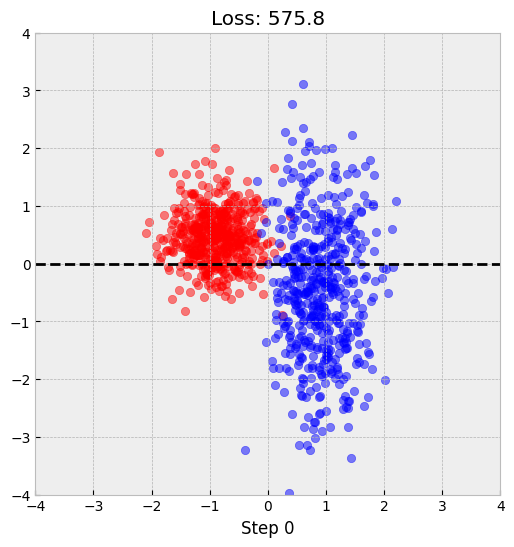

In [103]:
#animation code
fig, ax = plt.subplots(figsize=(6, 6))

plt.scatter(X[Y==1,0],X[Y==1,1], marker='o', alpha=.5, color="red")
plt.scatter(X[Y==0,0],X[Y==0,1], marker='o', alpha=.5, color="blue")

ax.set_xlim(c, d)
ax.set_ylim(c, d)


# x-values for decision boundary
x_vals = np.linspace(*ax.get_xlim(), 1000)

# Initialize empty line
(line,) = ax.plot([], [], lw=2, color="black", linestyle='--')

# Animation update function
def update(frame):
    w1, w2, b = weights[frame]

    # Avoid division by zero, didn't end up mattering for my runs
    if abs(w2) < 1e-8:
        y_vals = np.full_like(x_vals, np.nan)
    else:
        y_vals = -(w1 * x_vals + b) / w2

    line.set_data(x_vals, y_vals)
    ax.set_xlabel(f"Step {frame}")
    ax.set_title(f'Loss: {round(losslist[frame], 1)}')

    return (line,)

# Create animation
anim = FuncAnimation(
    fig,
    update,
    frames=range(0, len(weights), 10), #render every 10 frames
    interval=100, #in milliseconds
    blit=True
)

plt.show()

In [104]:
#Run on colab or GPU, this took a while, you could also slash the quality
#anim.save("MATH5001HW1DL.gif", fps=10, dpi=180)
